In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Step 1: Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Step 2: Load the Dataset

In [5]:
df=pd.read_csv("/content/drive/MyDrive/24UAM077_ML/EX02/test.csv")
print(df.head())


   Age  Premium
0   18    10000
1   22    15000
2   23    18000
3   26    21000
4   28    24000


Step 3: Select Feature and Target


In [9]:
X = df[['Age']].values
y = df['Premium'].values


Step 4: Check for Missing Values

In [10]:
print(df[['Age','Premium']].isnull().sum())
df = df[['Age','Premium']].dropna()

X = df[['Age']].values
y = df['Premium'].values


Age        0
Premium    0
dtype: int64


Step 5: Define Linear Regression Class

In [11]:
class SimpleLinearRegression:

    def __init__(self):
        self.coefficients_ = None
        self.intercept_ = None
        self.r2score_ = None

    def fit(self, X, y):

        n = len(X)

        # Add column of ones
        X_b = np.c_[np.ones((n,1)), X]

        # Normal Equation
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

        self.intercept_ = self.coefficients_[0]

        # Predictions
        y_pred = X_b.dot(self.coefficients_)

        self.y_pred_ = y_pred

        # R² Score
        self.r2score_ = 1 - (
            np.sum((y-y_pred)**2) /
            np.sum((y-np.mean(y))**2)
        )

    def predict(self,X):

        X_b = np.c_[np.ones((len(X),1)), X]

        return X_b.dot(self.coefficients_)


Step 6: Train the Model

In [12]:
slr = SimpleLinearRegression()

slr.fit(X, y)


Step 7: Print Results

In [13]:
print("Intercept :", slr.intercept_)
print("Slope :", slr.coefficients_[1])
print("R² Score :", slr.r2score_)


Intercept : -10114.726027397352
Slope : 1172.9452054794542
R² Score : 0.9689086110984922


Step 8: Predict New premium

In [15]:
new_premium = np.array([[2000]])

price = slr.predict(new_premium)

print("Predicted Price:", price[0])


Predicted Price: 2335775.684931511


Step 9: Visualize the Regression Line

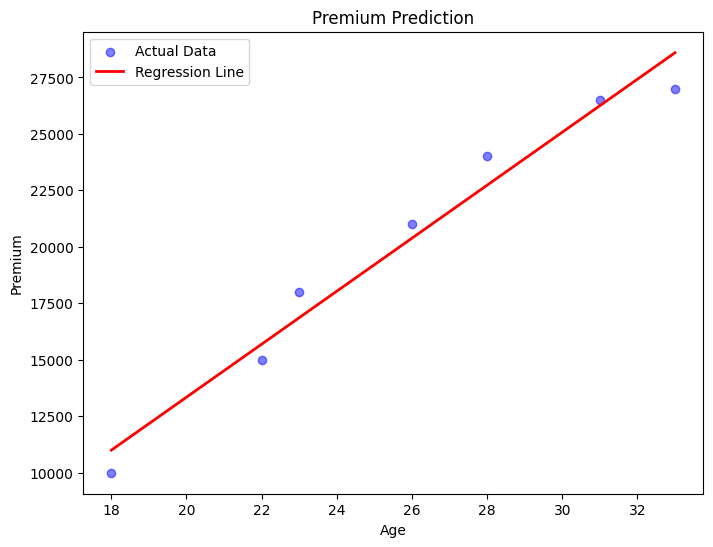

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')

plt.plot(X, slr.y_pred_, color='red', linewidth=2,
         label='Regression Line')

plt.title("Premium Prediction")
plt.xlabel("Age")
plt.ylabel("Premium")
plt.legend()

plt.show()
